In [1]:
from __future__ import annotations

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from quant_pml.runner import build_backtest
from quant_pml.strategies.factors.momentum import Momentum

from deep_momentum.config.project_experiment_config import ProjectExperimentConfig
from deep_momentum.config.project_trading_config import ProjectTradingConfig

QUANTILE = 0.1

In [2]:
strategy = Momentum(
    mode="long_short",
    quantile=QUANTILE,
)

In [3]:
strategy_name = strategy.__class__.__name__

preprocessor, runner = build_backtest(
    experiment_config=ProjectExperimentConfig(),
    trading_config=ProjectTradingConfig(),
    rebal_freq="ME",
)

Backtest on 2010-02-01 00:00:00 to 2024-12-31 00:00:00
Num Train Iterations: 179
Num Hedge Iterations: 3773
Num OOS Daily Points: 3755
Avg Num Stocks in Universe: 2533.43


In [4]:
res = runner(
    feature_processor=preprocessor,
    strategy=strategy,
)

Computing NAVs: 100%|██████████| 179/179 [00:00<00:00, 249.32it/s]


In [5]:
res.to_pandas().loc[["sharpe", "alpha_benchmark", "ir_benchmark"]]

,value
metric,
sharpe,0.228458
alpha_benchmark,-0.014841
ir_benchmark,-0.200716


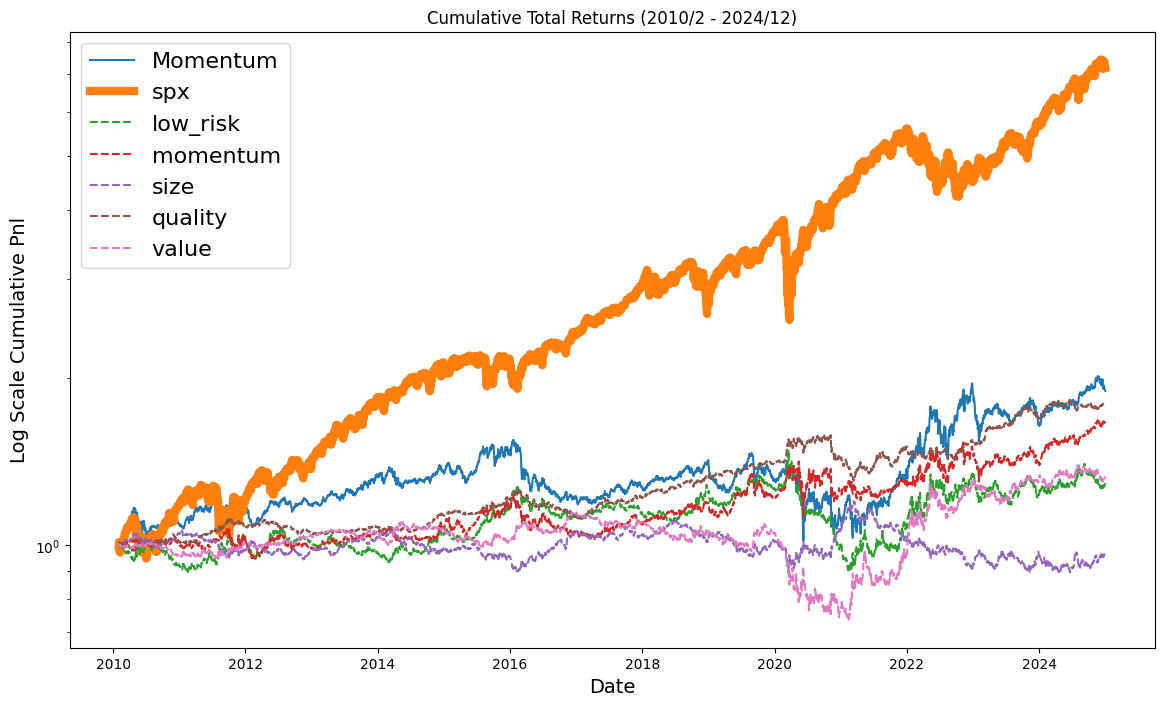

In [6]:
runner.plot_cumulative(
    strategy_name=strategy_name,
    include_factors=True,
)

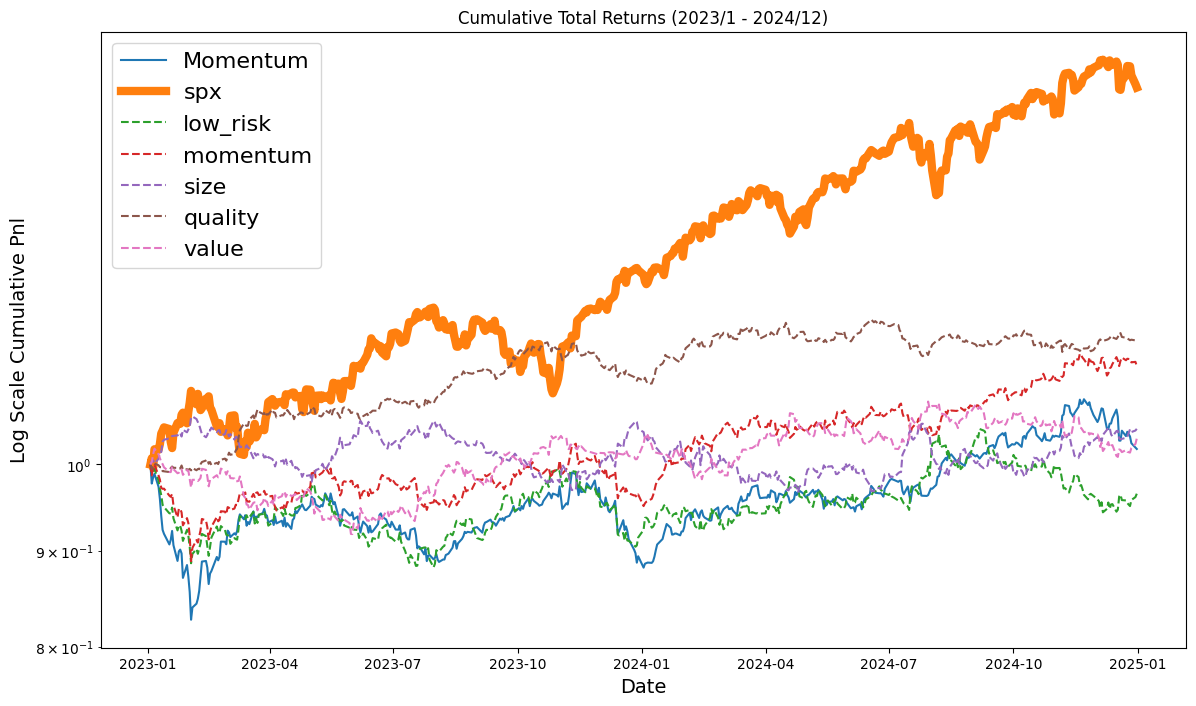

In [7]:
runner.plot_cumulative(
    strategy_name=strategy_name,
    include_factors=True,
    start_date="2023-01-01",
)

In [8]:
runner.get_metrics(start_date="2023-01-01", end_date=None)

StrategyStatistics:
* final_nav = 1.004968
* geom_avg_total_r = 0.002491
* geom_avg_xs_r = -0.049196
* std_xs_r = 0.121530
* min_xs_r = -0.033487
* max_xs_r = 0.020170
* skew = -0.616198
* kurtosis = 1.309573
* max_dd = -0.176299
* sharpe = -0.404805
* alpha_buy_hold = -0.255174
* tracking_error_buy_hold = 0.181557
* ir_buy_hold = -1.405473
* factor_loadings = {'low_risk': 0.22337796669573767, 'momentum': 0.9960156744254223, 'size': -0.04990433884770462, 'quality': 0.1214285460337895, 'value': 0.10020612955757026, 'spx-rf': 0.12314575340372633}
* alpha_benchmark = -0.066908
* alpha_benchmark_pvalue = 0.142108
* tracking_error_benchmark = 0.059556
* ir_benchmark = -1.123441
* ttest_pval = 0.965182
* levene_pval = 0.326814
* timing_ability_coef = 0.074066
* timing_ability_pval = 0.568796